In [1]:
import os
tmy_path = './'
if os.path.exists(tmy_path):
    print(f"'{tmy_path}' 내 파일 목록:")
    print(os.listdir(tmy_path))
else:
    print(f"❌ '{tmy_path}' 경로가 존재하지 않습니다.")

'./' 내 파일 목록:
['Data_extraction_2.0.1.ipynb', 'temp_test204.py', '.DS_Store', 'LICENSE', 'requirements.txt', 'Nasdaq100_60years_daily.csv', 'README.md', 'Stock_Classification_2.0.4.ipynb', '.gitignore', 'Stock_Classification_2.0.2.ipynb', '.git', '.vscode', 'create_2_0_4.py', 'Stock_Classification_2.0.1.ipynb', 'Stock_Classification_2.0.3.ipynb', 'SnP500_60years_daily.csv']


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

# ==========================================
# 1. 환경 설정 (Configuration)
# ==========================================
class Config:
    # 분석 및 학습에 사용할 데이터 소스 경로
    DATA_SOURCES = {
        'S&P 500': './SnP500_60years_daily.csv',
        'Nasdaq 100': './Nasdaq100_60years_daily.csv'
    }
    WINDOW_SIZE = 5      # 과거 며칠간의 데이터를 특징(Feature)으로 사용할지 설정
    THRESHOLD = 0.002    # '상승'으로 판단할 수익률 임계값 (0.2% 이상 시 1, 미만 시 0)
    TRAIN_SPLIT = 0.8    # 전체 데이터 중 학습에 사용할 비율 (80% 학습, 20% 테스트)

# ==========================================
# 2. 데이터 처리 클래스 (Data Processing)
# ==========================================
class DataProcessor:
    """데이터 로딩, 고급 기술적 지표 계산 및 피처 스케일링 수행"""
    def __init__(self, file_path):
        self.file_path = file_path
        self.features = []
        from sklearn.preprocessing import StandardScaler
        self.scaler = StandardScaler()

    def load_and_clean(self):
        """CSV 로드 및 기본 전처리 (날짜 정렬 및 수치형 변환)"""
        import pandas as pd
        df = pd.read_csv(self.file_path)
        df.columns = [c.lower() for c in df.columns]
        df = df.sort_values(by='date').reset_index(drop=True)
        cols = ['open', 'high', 'low', 'close', 'volume']
        df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
        return df

    def add_features(self, df):
        """학술 연구용 고급 보조지표 및 Lag 데이터 생성"""
        import pandas as pd
        import numpy as np
        
        # 기본 변동성 지표
        df['return'] = df['close'].pct_change()
        df['vol_change'] = df['volume'].pct_change()
        df['high_low_gap'] = (df['high'] - df['low']) / df['open']

        # RSI
        delta = df['close'].diff()
        gain = delta.where(delta > 0, 0).rolling(window=14).mean()
        loss = -delta.where(delta < 0, 0).rolling(window=14).mean()
        rs = gain / loss
        df['RSI'] = 100 - (100 / (1 + rs))

        # MACD & Histogram
        exp1 = df['close'].ewm(span=12, adjust=False).mean()
        exp2 = df['close'].ewm(span=26, adjust=False).mean()
        df['MACD'] = (exp1 - exp2) / df['close'] 
        df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
        df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

        # Bollinger Bands & Pct
        df['MA20'] = df['close'].rolling(window=20).mean()
        df['std20'] = df['close'].rolling(window=20).std()
        df['BB_Upper'] = df['MA20'] + (df['std20'] * 2)
        df['BB_Lower'] = df['MA20'] - (df['std20'] * 2)
        df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['MA20']
        
        # Stochastic
        low_min = df['low'].rolling(window=14).min()
        high_max = df['high'].rolling(window=14).max()
        df['Stochastic_K'] = 100 * (df['close'] - low_min) / (high_max - low_min)
        df['Stochastic_D'] = df['Stochastic_K'].rolling(window=3).mean()

        # ATR
        tr = pd.concat([df['high'] - df['low'],
                        abs(df['high'] - df['close'].shift()),
                        abs(df['low'] - df['close'].shift())], axis=1).max(axis=1)
        df['ATR'] = tr.rolling(window=14).mean() / df['close']

        # Exponential Moving Averages (EMA)
        for span in [5, 10, 20, 50]:
            df[f'EMA_{span}'] = df['close'].ewm(span=span, adjust=False).mean() / df['close']

        # Williams %R
        df['Williams_R'] = (high_max - df['close']) / (high_max - low_min) * -100
        
        # Rate of Change (ROC)
        df['ROC_10'] = df['close'].pct_change(periods=10)
        df['ROC_20'] = df['close'].pct_change(periods=20)

        # 시차(Lag) 피처
        lag_features = {}
        for i in range(1, Config.WINDOW_SIZE + 1):
            lag_features[f'return_lag_{i}'] = df['return'].shift(i)
            lag_features[f'vol_lag_{i}'] = df['vol_change'].shift(i)
        
        df = pd.concat([df, pd.DataFrame(lag_features)], axis=1)

        self.features = ['return', 'vol_change', 'high_low_gap', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
                        'BB_Width', 'Stochastic_K', 'Stochastic_D', 'ATR', 'Williams_R', 'ROC_10', 'ROC_20'] + \
                        [f'EMA_{s}' for s in [5, 10, 20, 50]] + \
                        [f'return_lag_{i}' for i in range(1, Config.WINDOW_SIZE + 1)] + \
                        [f'vol_lag_{i}' for i in range(1, Config.WINDOW_SIZE + 1)]

        df['target'] = (df['return'].shift(-1) > Config.THRESHOLD).astype(int)
        df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
        return df

    def split_data(self, df):
        """데이터 분리 및 스케일링(Scaling)"""
        import pandas as pd
        X = df[self.features]
        y = df['target']
        split_idx = int(len(df) * Config.TRAIN_SPLIT)
        
        X_train_raw = X[:split_idx]
        X_test_raw = X[split_idx:]
        
        # 스케일링 (Data Leakage 방지를 위해 Train 데이터로만 fit)
        X_train_scaled = self.scaler.fit_transform(X_train_raw)
        X_test_scaled = self.scaler.transform(X_test_raw)
        
        # Feature Importance 유지를 위해 DataFrame 복원
        X_train = pd.DataFrame(X_train_scaled, columns=self.features, index=X_train_raw.index)
        X_test = pd.DataFrame(X_test_scaled, columns=self.features, index=X_test_raw.index)
        
        y_train = y[:split_idx]
        y_test = y[split_idx:]
        
        df_test = df.iloc[split_idx:].copy()
        df_test['Next_Return'] = df_test['return'].shift(-1).fillna(0)
        
        return X_train, X_test, y_train, y_test, df_test

class ModelManager:
    """연구 목적을 위한 TimeSeriesSplit 최적화, 스케일링 기반 다양한 앙상블 학습 모델링"""
    def __init__(self):
        from lightgbm import LGBMClassifier
        from sklearn.ensemble import VotingClassifier, RandomForestClassifier
        from xgboost import XGBClassifier
        from sklearn.linear_model import LogisticRegression

        # 스케일링이 적용되었으므로 선형 모델(LogisticRegression) 추가 가능
        self.base_xgb = XGBClassifier(random_state=42)
        self.base_rf = RandomForestClassifier(random_state=42, class_weight='balanced')
        self.base_lgbm = LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')
        self.base_lr = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
        
        self.models = {}

    def train_and_predict(self, X_train, y_train, X_test, y_test):
        import numpy as np
        from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
        from sklearn.metrics import accuracy_score, classification_report, f1_score
        from sklearn.ensemble import VotingClassifier

        print("\n[TimeSeriesSplit 기반 하이퍼파라미터 최적화 시작 (Data Leakage 완전 차단 모드)]")
        tscv = TimeSeriesSplit(n_splits=3)
        
        xgb_params = {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.03, 0.05],
            'max_depth': [3, 4, 5],
            'subsample': [0.8],
            'colsample_bytree': [0.8]
        }
        
        rf_params = {
            'n_estimators': [100, 200],
            'max_depth': [5, 7, 10],
            'min_samples_split': [2, 5]
        }
        
        lgbm_params = {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.03, 0.05],
            'max_depth': [3, 4, 5]
        }
        
        lr_params = {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2']
        }
        
        # XGB 클래스 불균형 보정
        neg_count = sum(y_train == 0)
        pos_count = sum(y_train == 1)
        scale_pos = neg_count / pos_count if pos_count > 0 else 1.0
        self.base_xgb.set_params(scale_pos_weight=scale_pos)
        
        # Time-Decay Sample Weights (최근 데이터일수록 가중치 부여)
        # 0.1 ~ 1.0 범위로 선형적으로 증가 (오래된 데이터는 영향력 축소)
        sample_weights = np.linspace(0.1, 1.0, len(y_train))
        
        print(" -> 최적의 파라미터를 탐색 중입니다... (1~2분 소요)")
        search_xgb = RandomizedSearchCV(self.base_xgb, xgb_params, n_iter=5, cv=tscv, scoring='f1_macro', n_jobs=-1, random_state=42)
        search_rf = RandomizedSearchCV(self.base_rf, rf_params, n_iter=5, cv=tscv, scoring='f1_macro', n_jobs=-1, random_state=42)
        search_lgbm = RandomizedSearchCV(self.base_lgbm, lgbm_params, n_iter=5, cv=tscv, scoring='f1_macro', n_jobs=-1, random_state=42)
        search_lr = RandomizedSearchCV(self.base_lr, lr_params, n_iter=4, cv=tscv, scoring='f1_macro', n_jobs=-1, random_state=42)
        
        # SearchCV fit은 일부 모델에서 sample_weight를 지원하지 않을 수 있으므로, 
        # 최적 파라미터 획득 후 최종 fit 과정에서만 sample_weight 적용합니다.
        search_xgb.fit(X_train, y_train)
        search_rf.fit(X_train, y_train)
        search_lgbm.fit(X_train, y_train)
        search_lr.fit(X_train, y_train)
        
        best_xgb = search_xgb.best_estimator_
        best_rf = search_rf.best_estimator_
        best_lgbm = search_lgbm.best_estimator_
        best_lr = search_lr.best_estimator_
        
        ensemble = VotingClassifier(estimators=[('XGB', best_xgb), ('RF', best_rf), ('LGBM', best_lgbm), ('LR', best_lr)], voting='soft')
        
        self.models = {
            'XGB': best_xgb,
            'RF': best_rf,
            'LGBM': best_lgbm,
            'LR': best_lr,
            'Ensemble': ensemble
        }
        
        for name, model in self.models.items():
            print(f"\n[{name} 모델 평가]")
            # 최종 학습에 Time-Decay 가중치 적용 (일부 모델 미지원 예외 처리)
            try:
                model.fit(X_train, y_train, sample_weight=sample_weights)
            except TypeError:
                try:
                    # Ensemble의 경우 fit_params로 전달 필요할 수 있음
                    model.fit(X_train, y_train, XGB__sample_weight=sample_weights, RF__sample_weight=sample_weights, LGBM__sample_weight=sample_weights, LR__sample_weight=sample_weights)
                except Exception:
                    # 완벽하게 호환되지 않는 경우 일반 학습 진행
                    model.fit(X_train, y_train)
            
            # [수정] Test Set Snooping Bias 방지: 최적 임계값은 오직 Train Set 내부에서만 탐색!
            probs_train = model.predict_proba(X_train)[:, 1]
            best_thresh = 0.5
            best_f1 = 0
            for th in np.arange(0.40, 0.60, 0.01):
                preds_train = (probs_train > th).astype(int)
                f1 = f1_score(y_train, preds_train, average='macro')
                if f1 > best_f1:
                    best_f1 = f1
                    best_thresh = th
            
            # 확정된(Blind) 임계값을 Test Set에 적용 (Real Out-of-Sample Evaluation)
            probs_test = model.predict_proba(X_test)[:, 1]
            final_preds = (probs_test > best_thresh).astype(int)
            acc = accuracy_score(y_test, final_preds)
            macro_f1 = f1_score(y_test, final_preds, average='macro')
            
            print(f" - Train 기준 최적 Threshold: {best_thresh:.2f} (Test 누수 없음)")
            print(f" - Out-of-Sample Accuracy: {acc:.4f}")
            print(f" - Out-of-Sample Macro F1: {macro_f1:.4f}")
            print(classification_report(y_test, final_preds))

if __name__ == "__main__":
    for asset_name, path in Config.DATA_SOURCES.items():
        if not os.path.exists(path):
            print(f"❌ 파일을 찾을 수 없습니다: {path}")
            continue

        print(f"\n🚀 {asset_name} 파이프라인 시작...")
        processor = DataProcessor(path)
        raw_df = processor.load_and_clean()
        processed_df = processor.add_features(raw_df)
        X_train, X_test, y_train, y_test, df_test = processor.split_data(processed_df)
        model_manager = ModelManager()
        model_manager.train_and_predict(X_train, y_train, X_test, y_test)
        print(f"✅ {asset_name} 파이프라인 완료\n" + "="*50)



🚀 S&P 500 파이프라인 시작...

[TimeSeriesSplit 기반 하이퍼파라미터 최적화 시작 (Data Leakage 완전 차단 모드)]
 -> 최적의 파라미터를 탐색 중입니다... (1~2분 소요)


/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encounte


[XGB 모델 평가]
 - Train 기준 최적 Threshold: 0.52 (Test 누수 없음)
 - Out-of-Sample Accuracy: 0.5768
 - Out-of-Sample Macro F1: 0.5424
              precision    recall  f1-score   support

           0       0.62      0.73      0.67      1950
           1       0.49      0.36      0.42      1389

    accuracy                           0.58      3339
   macro avg       0.55      0.55      0.54      3339
weighted avg       0.56      0.58      0.56      3339


[RF 모델 평가]
 - Train 기준 최적 Threshold: 0.52 (Test 누수 없음)
 - Out-of-Sample Accuracy: 0.5756
 - Out-of-Sample Macro F1: 0.5327
              precision    recall  f1-score   support

           0       0.61      0.75      0.67      1950
           1       0.49      0.33      0.39      1389

    accuracy                           0.58      3339
   macro avg       0.55      0.54      0.53      3339
weighted avg       0.56      0.58      0.56      3339


[LGBM 모델 평가]
 - Train 기준 최적 Threshold: 0.52 (Test 누수 없음)
 - Out-of-Sample Accuracy: 0.5720
 - Ou

/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: Runti

 - Train 기준 최적 Threshold: 0.52 (Test 누수 없음)
 - Out-of-Sample Accuracy: 0.5798
 - Out-of-Sample Macro F1: 0.5282
              precision    recall  f1-score   support

           0       0.61      0.78      0.68      1950
           1       0.49      0.30      0.37      1389

    accuracy                           0.58      3339
   macro avg       0.55      0.54      0.53      3339
weighted avg       0.56      0.58      0.55      3339

✅ S&P 500 파이프라인 완료

🚀 Nasdaq 100 파이프라인 시작...

[TimeSeriesSplit 기반 하이퍼파라미터 최적화 시작 (Data Leakage 완전 차단 모드)]
 -> 최적의 파라미터를 탐색 중입니다... (1~2분 소요)


/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: Runti


[XGB 모델 평가]
 - Train 기준 최적 Threshold: 0.50 (Test 누수 없음)
 - Out-of-Sample Accuracy: 0.5137
 - Out-of-Sample Macro F1: 0.5029
              precision    recall  f1-score   support

           0       0.53      0.63      0.58      1080
           1       0.48      0.39      0.43       966

    accuracy                           0.51      2046
   macro avg       0.51      0.51      0.50      2046
weighted avg       0.51      0.51      0.51      2046


[RF 모델 평가]
 - Train 기준 최적 Threshold: 0.50 (Test 누수 없음)
 - Out-of-Sample Accuracy: 0.5181
 - Out-of-Sample Macro F1: 0.5047
              precision    recall  f1-score   support

           0       0.54      0.65      0.59      1080
           1       0.49      0.37      0.42       966

    accuracy                           0.52      2046
   macro avg       0.51      0.51      0.50      2046
weighted avg       0.51      0.52      0.51      2046


[LGBM 모델 평가]
 - Train 기준 최적 Threshold: 0.50 (Test 누수 없음)
 - Out-of-Sample Accuracy: 0.5112
 - Ou

/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: Runti

 - Train 기준 최적 Threshold: 0.50 (Test 누수 없음)
 - Out-of-Sample Accuracy: 0.5127
 - Out-of-Sample Macro F1: 0.4991
              precision    recall  f1-score   support

           0       0.53      0.64      0.58      1080
           1       0.48      0.37      0.42       966

    accuracy                           0.51      2046
   macro avg       0.51      0.51      0.50      2046
weighted avg       0.51      0.51      0.50      2046

✅ Nasdaq 100 파이프라인 완료


/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/tommyboy/miniconda3/envs/DongnaeFriends/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: Runti


📊 Nasdaq 100 모델 피처 중요도 분석:


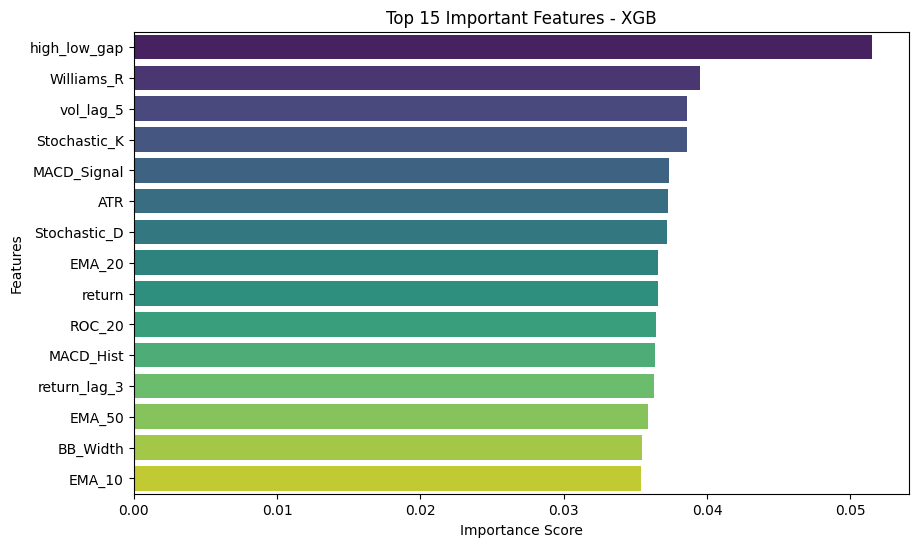

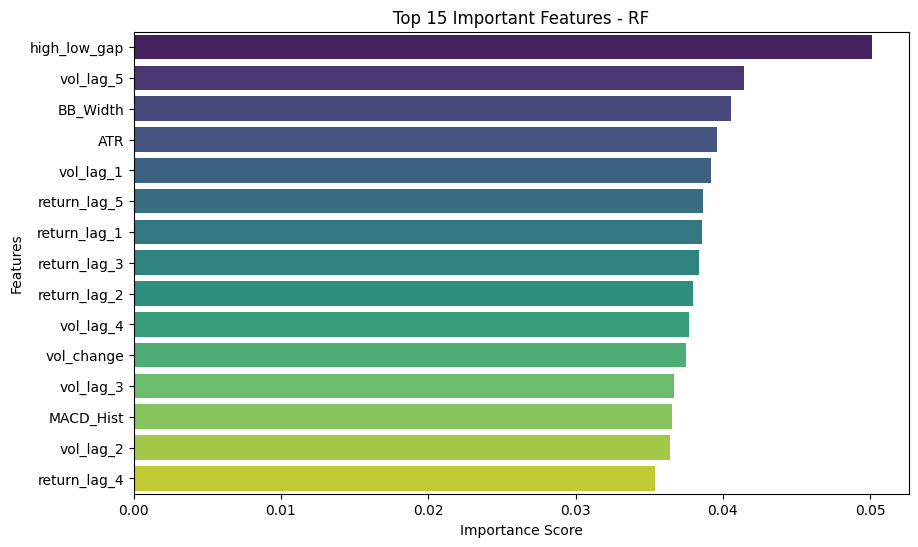

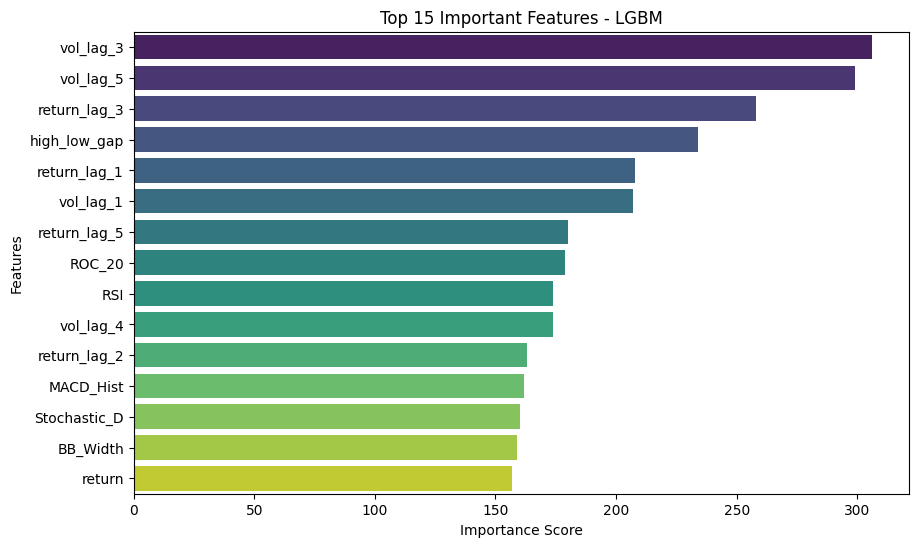


⚠️ LR 모델은 피처 중요도를 제공하지 않아 시각화를 생략합니다.

⚠️ Ensemble 모델은 피처 중요도를 제공하지 않아 시각화를 생략합니다.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_feature_importance(model_manager, features):
    """학습된 모델들의 피처 중요도를 시각화합니다."""
    for name, model in model_manager.models.items():
        if not hasattr(model, 'feature_importances_'):
            print(f"\n⚠️ {name} 모델은 피처 중요도를 제공하지 않아 시각화를 생략합니다.")
            continue
            
        importance = model.feature_importances_
        feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importance})
        feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis', hue='Feature', legend=False)
        plt.title(f'Top 15 Important Features - {name}')
        plt.xlabel('Importance Score')
        plt.ylabel('Features')
        plt.show()

# 마지막으로 분석된 자산의 모델 정보를 바탕으로 중요도 출력
print(f"\n📊 {asset_name} 모델 피처 중요도 분석:")
plot_feature_importance(model_manager, processor.features)


In [4]:
from datetime import datetime, timedelta

def get_next_day_prediction(asset_name, processor, model_manager):
    """가장 최근 데이터를 바탕으로 내일의 주가 상승/하락 예측 결과 제공"""
    # 1. 가장 최근(마지막 행) 데이터 추출
    last_row_features = X_test.iloc[[-1]]
    last_row_full = df_test.iloc[-1]

    # 날짜 처리 (YYYYMMDD 숫자를 날짜 객체로 변환)
    last_date_str = str(int(last_row_full['date']))
    last_date_obj = datetime.strptime(last_date_str, '%Y%m%d')
    # 다음 거래일 계산
    next_date_obj = last_date_obj + timedelta(days=1)

    # 2. 모델별 예측 (1: 상승, 0: 하락/보합)
    predictions = {}
    for name, model in model_manager.models.items():
        pred = model.predict(last_row_features)[0]
        prob = model.predict_proba(last_row_features)[0][1] # 상승 확률
        predictions[name] = {'signal': pred, 'prob': prob}

    # 3. 결과 리포트 출력
    print(f"\n{'='*60}")
    print(f" 📈 [ {asset_name} - AI 주가 예측 리포트 ] ")
    print(f"{'='*60}")
    print(f" 📅 [1] 데이터 기준 거래일  : {last_date_obj.strftime('%Y-%m-%d')}")
    print(f" 🎯 [2] 예측 대상 목표일    : {next_date_obj.strftime('%Y-%m-%d')} (익일)")
    print(f"{'='*60}")

    print(f"[AI 모델별 분석 결과]")
    for name, res in predictions.items():
        direction = "상승 우세 ↑" if res['signal'] == 1 else "하락/보합 우세 ↓"
        print(f" - {name:<4}: {direction} (상승 확률: {res['prob']*100:.1f}%)")

    print(f"\n[종합 의견]")
    # 두 모델의 평균 확률 계산
    avg_prob = sum(res['prob'] for res in predictions.values()) / len(predictions)
    if avg_prob >= 0.6:
        opinion = "상승 가능성이 높습니다. 긍정적인 관점을 유지하세요."
    elif avg_prob >= 0.45:
        opinion = "방향성이 모호합니다. 시장 상황을 좀 더 관망하세요."
    else:
        opinion = "하락 또는 보합 가능성이 높으므로 주의가 필요합니다."

    print(f" ➔ {opinion}")
    print(f"{'='*60}")

# Nasdaq 100 기준으로 예측 실행 (backtester 인자 제거)
get_next_day_prediction("Nasdaq 100", processor, model_manager)


 📈 [ Nasdaq 100 - AI 주가 예측 리포트 ] 
 📅 [1] 데이터 기준 거래일  : 2026-06-05
 🎯 [2] 예측 대상 목표일    : 2026-06-06 (익일)
[AI 모델별 분석 결과]
 - XGB : 상승 우세 ↑ (상승 확률: 58.4%)
 - RF  : 상승 우세 ↑ (상승 확률: 59.8%)
 - LGBM: 상승 우세 ↑ (상승 확률: 62.6%)
 - LR  : 상승 우세 ↑ (상승 확률: 54.8%)
 - Ensemble: 상승 우세 ↑ (상승 확률: 58.9%)

[종합 의견]
 ➔ 방향성이 모호합니다. 시장 상황을 좀 더 관망하세요.


In [5]:
from datetime import datetime, timedelta
import pandas as pd

def show_last_month_performance(asset_name, processor, model_manager, df_test, X_test):
    """최근 한 달간(20거래일)의 일별 AI 예측 결과(확률 포함)를 요약하여 출력합니다."""
    print(f"\n{'='*90}")
    print(f" 📊 [ {asset_name} - 최근 20거래일 AI 예측 상세 히스토리 ] ")
    print(f"{'='*90}")
    print(f" {'기준 거래일':<11} | {'예측 목표일':<11} | {'XGB 예측(확률)':<18} | {'RF 예측(확률)':<18}")
    print(f" {'-'*88}")

    # 최근 20개 데이터 추출
    lookback_period = 20
    recent_X = X_test.tail(lookback_period)
    recent_df = df_test.tail(lookback_period)

    for i in range(len(recent_df)):
        row = recent_df.iloc[i]
        feat = recent_X.iloc[[i]]

        # 날짜 계산
        base_date = datetime.strptime(str(int(row['date'])), '%Y%m%d')
        target_date = base_date + timedelta(days=1)

        # 모델 예측 및 확률 추출
        xgb_prob = model_manager.models['XGB'].predict_proba(feat)[0][1]
        rf_prob = model_manager.models['RF'].predict_proba(feat)[0][1]

        xgb_label = "상승" if xgb_prob > 0.5 else "하락"
        rf_label = "상승" if rf_prob > 0.5 else "하락"

        xgb_display = f"{xgb_label}({xgb_prob*100:4.1f}%)"
        rf_display = f"{rf_label}({rf_prob*100:4.1f}%)"

        print(f" {base_date.strftime('%Y-%m-%d'):<11} | {target_date.strftime('%Y-%m-%d'):<11} | {xgb_display:<18} | {rf_display:<18}")

    print(f"{'='*90}")
    print("* [확률]은 내일 주가가 설정된 임계치(Threshold) 이상 상승할 가능성을 의미합니다.")

# Nasdaq 100 기준으로 히스토리 출력
show_last_month_performance("Nasdaq 100", processor, model_manager, df_test, X_test)


 📊 [ Nasdaq 100 - 최근 20거래일 AI 예측 상세 히스토리 ] 
 기준 거래일      | 예측 목표일      | XGB 예측(확률)         | RF 예측(확률)         
 ----------------------------------------------------------------------------------------
 2026-05-08  | 2026-05-09  | 하락(49.5%)          | 상승(50.4%)         
 2026-05-11  | 2026-05-12  | 하락(47.5%)          | 하락(45.3%)         
 2026-05-12  | 2026-05-13  | 상승(50.5%)          | 상승(50.6%)         
 2026-05-13  | 2026-05-14  | 하락(46.9%)          | 하락(47.3%)         
 2026-05-14  | 2026-05-15  | 하락(46.4%)          | 하락(47.4%)         
 2026-05-15  | 2026-05-16  | 하락(49.2%)          | 상승(51.4%)         
 2026-05-18  | 2026-05-19  | 상승(58.8%)          | 상승(55.8%)         
 2026-05-19  | 2026-05-20  | 상승(50.8%)          | 하락(49.8%)         
 2026-05-20  | 2026-05-21  | 상승(51.2%)          | 상승(52.3%)         
 2026-05-21  | 2026-05-22  | 상승(50.5%)          | 하락(48.2%)         
 2026-05-22  | 2026-05-23  | 상승(50.6%)          | 상승(51.4%)         
 2026-05-26  | 2026-05-27  | 하락(47.8%

In [6]:
def show_prediction_vs_actual(asset_name, model_manager, df_test, X_test):
    """AI 예측(확률)과 실제 지수 등락 결과를 비교하여 출력합니다."""
    print(f"\n{'='*125}")
    print(f" 🎯 [ {asset_name} - AI 예측 vs 실제 시장 결과 비교 (최근 20일) ] ")
    print(f"{'='*125}")
    print(f" {'기준 거래일':<11} | {'예측 목표일':<11} | {'XGB(확률)':<15} | {'RF(확률)':<15} | {'실제 수익률':<10} | {'결과':<6} | {'적중'}")
    print(f" {'-'*123}")

    lookback_period = 20
    recent_X = X_test.tail(lookback_period)
    recent_df = df_test.tail(lookback_period)

    hit_count = 0
    for i in range(len(recent_df)):
        row = recent_df.iloc[i]
        feat = recent_X.iloc[[i]]

        base_date = datetime.strptime(str(int(row['date'])), '%Y%m%d')
        target_date = base_date + timedelta(days=1)

        # 모델 예측 확률
        xgb_prob = model_manager.models['XGB'].predict_proba(feat)[0][1]
        rf_prob = model_manager.models['RF'].predict_proba(feat)[0][1]

        # 실제 결과 (Next_Return 이용)
        actual_ret = row['Next_Return']
        actual_label = "상승" if actual_ret > 0 else "하락"

        # 예측 적중 여부 (두 모델의 다수결 혹은 마스터 시그널 기준 - 여기서는 단순 표시)
        # 여기서는 XGB 기준으로 단순 적중 여부 계산 예시
        pred_label = "상승" if xgb_prob > 0.5 else "하락"
        is_hit = "O" if pred_label == actual_label else "X"
        if is_hit == "O": hit_count += 1

        xgb_display = f"{pred_label}({xgb_prob*100:4.1f}%)"
        rf_display = f"{'상승' if rf_prob > 0.5 else '하락'}({rf_prob*100:4.1f}%)"

        print(f" {base_date.strftime('%Y-%m-%d'):<11} | {target_date.strftime('%Y-%m-%d'):<11} | {xgb_display:<15} | {rf_display:<15} | {actual_ret*100:>9.2f}% | {actual_label:<6} | {is_hit}")

    print(f"{'='*125}")
    print(f"* 최근 20일 중 XGB 모델 기준 방향 적중 횟수: {hit_count} / 20 ({hit_count/20*100:.1f}%)")
    print("* 실제 수익률은 '예측 목표일'의 종가 기준 등락률입니다.")

# 실행
show_prediction_vs_actual("Nasdaq 100", model_manager, df_test, X_test)


 🎯 [ Nasdaq 100 - AI 예측 vs 실제 시장 결과 비교 (최근 20일) ] 
 기준 거래일      | 예측 목표일      | XGB(확률)         | RF(확률)          | 실제 수익률     | 결과     | 적중
 ---------------------------------------------------------------------------------------------------------------------------
 2026-05-08  | 2026-05-09  | 하락(49.5%)       | 상승(50.4%)       |      0.29% | 상승     | X
 2026-05-11  | 2026-05-12  | 하락(47.5%)       | 하락(45.3%)       |     -0.87% | 하락     | O
 2026-05-12  | 2026-05-13  | 상승(50.5%)       | 상승(50.6%)       |      1.04% | 상승     | O
 2026-05-13  | 2026-05-14  | 하락(46.9%)       | 하락(47.3%)       |      0.73% | 상승     | X
 2026-05-14  | 2026-05-15  | 하락(46.4%)       | 하락(47.4%)       |     -1.54% | 하락     | O
 2026-05-15  | 2026-05-16  | 하락(49.2%)       | 상승(51.4%)       |     -0.45% | 하락     | O
 2026-05-18  | 2026-05-19  | 상승(58.8%)       | 상승(55.8%)       |     -0.61% | 하락     | X
 2026-05-19  | 2026-05-20  | 상승(50.8%)       | 하락(49.8%)       |      1.66% | 상승     | O
 2026-05-20  | 2026-0